# ML - Aprendizaje No Supervisado: Cáncer de Boca con K-Means

Si bien la mayoría de los ejemplos de *Machine Learning* que se presentan de forma introductoria suelen basarse en aprendizaje supervisado, en muchos casos reales los datos no están etiquetados. En esta práctica vamos a usar técnicas de aprendizaje no supervisado para agrupar imágenes de cáncer de boca por similitud visual. Para facilitar la interpretación, primero convertimos las imágenes a escala de grises, las redimensionamos y luego aplicamos PCA y K-Means. El valor de k no depende del número de muestras, sino de cuántos grupos queremos y qué tan bien se separan visualmente; por eso aquí se justifica con la estructura de las imágenes y no con el tamaño del dataset.


## 1. Carga del dataset local

Buscamos imágenes dentro de `C:\Users\elmer\Documents\SIS420\archive`. Para simplificar el análisis, las imágenes se convierten a escala de grises y se redimensionan antes de agruparlas. Si más adelante agregas carpetas con etiquetas, el notebook también puede detectarlas.


In [2]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

In [3]:
data_root = Path(r'C:\Users\elmer\Documents\archive\all unlabeled')
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
image_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in image_extensions])

if not image_paths:
    raise FileNotFoundError(f'No se encontraron imágenes en {data_root}')

print(f'Imágenes encontradas: {len(image_paths)}')
print('Primeras rutas:')
for path in image_paths[:5]:
    print(' -', path)

Imágenes encontradas: 10002
Primeras rutas:
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0001.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0002.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0003.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0004.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0005.jpg


In [4]:
def load_images(paths, image_size=(32, 32), max_images=None):
    selected_paths = paths if max_images is None else paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert('L').resize(image_size)
            image_arrays.append(np.asarray(img, dtype=np.float32) / 255.0)
    images = np.stack(image_arrays)
    flat = images.reshape(len(images), -1)
    return images, flat, selected_paths

max_images = None
images, X, used_paths = load_images(image_paths, image_size=(32, 32), max_images=max_images)
print('Shape de imágenes:', images.shape)
print('Shape de X:', X.shape)

Shape de imágenes: (10002, 32, 32)
Shape de X: (10002, 1024)


In [16]:
folder_labels = [p.parent.name for p in used_paths]
unique_folders = sorted(set(folder_labels))

if len(unique_folders) > 1:
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    y = encoder.fit_transform(folder_labels)
    target_names = encoder.classes_
    print('Etiquetas detectadas desde carpetas:', list(target_names))
else:
    y = None
    target_names = None
    print('No se detectaron etiquetas útiles. El notebook continuará como clustering + pseudoetiquetado manual.')

No se detectaron etiquetas útiles. El notebook continuará como clustering + pseudoetiquetado manual.


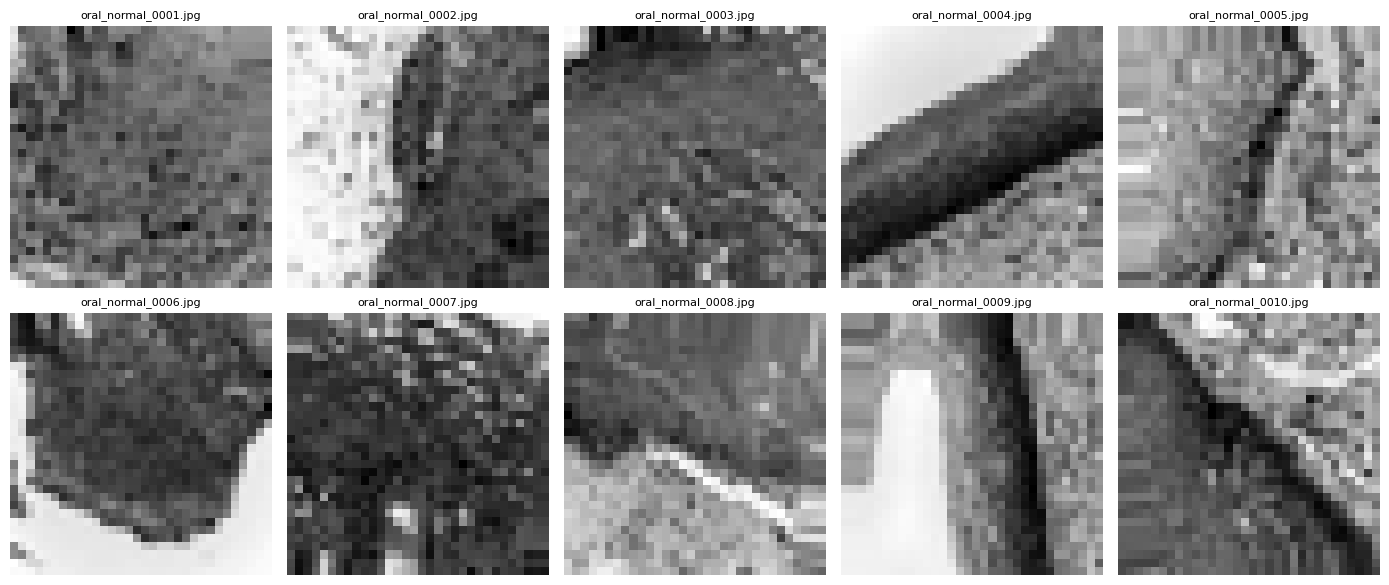

In [17]:
n_show = min(10, len(images))
cols = 5
rows = math.ceil(n_show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
axes = np.array(axes).reshape(-1)

for idx in range(len(axes)):
    axes[idx].axis('off')

for idx in range(n_show):
    axes[idx].imshow(images[idx], cmap='gray')
    title = used_paths[idx].name
    axes[idx].set_title(title[:22], fontsize=8)

plt.tight_layout()
plt.show()

Silhouette score del clustering real (muestra de 2000 imágenes): 0.1443


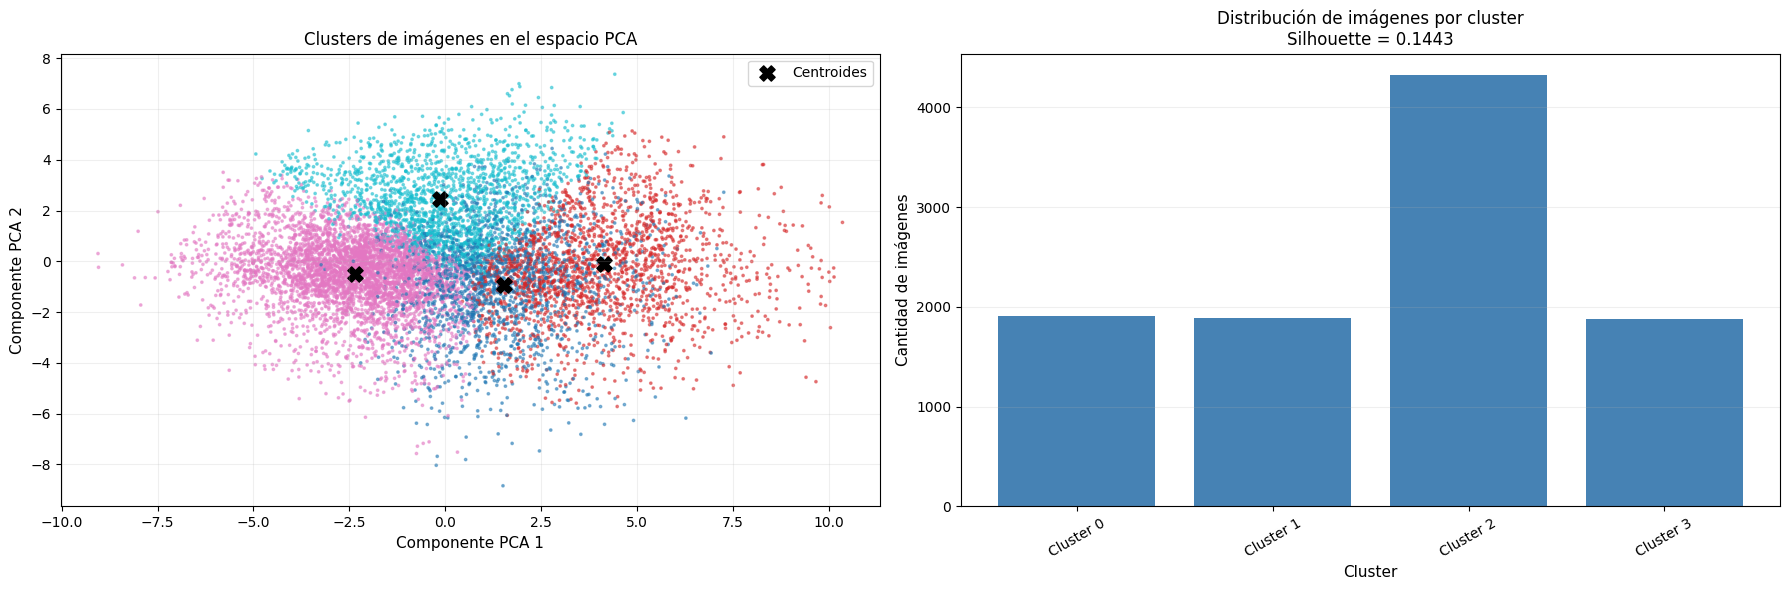

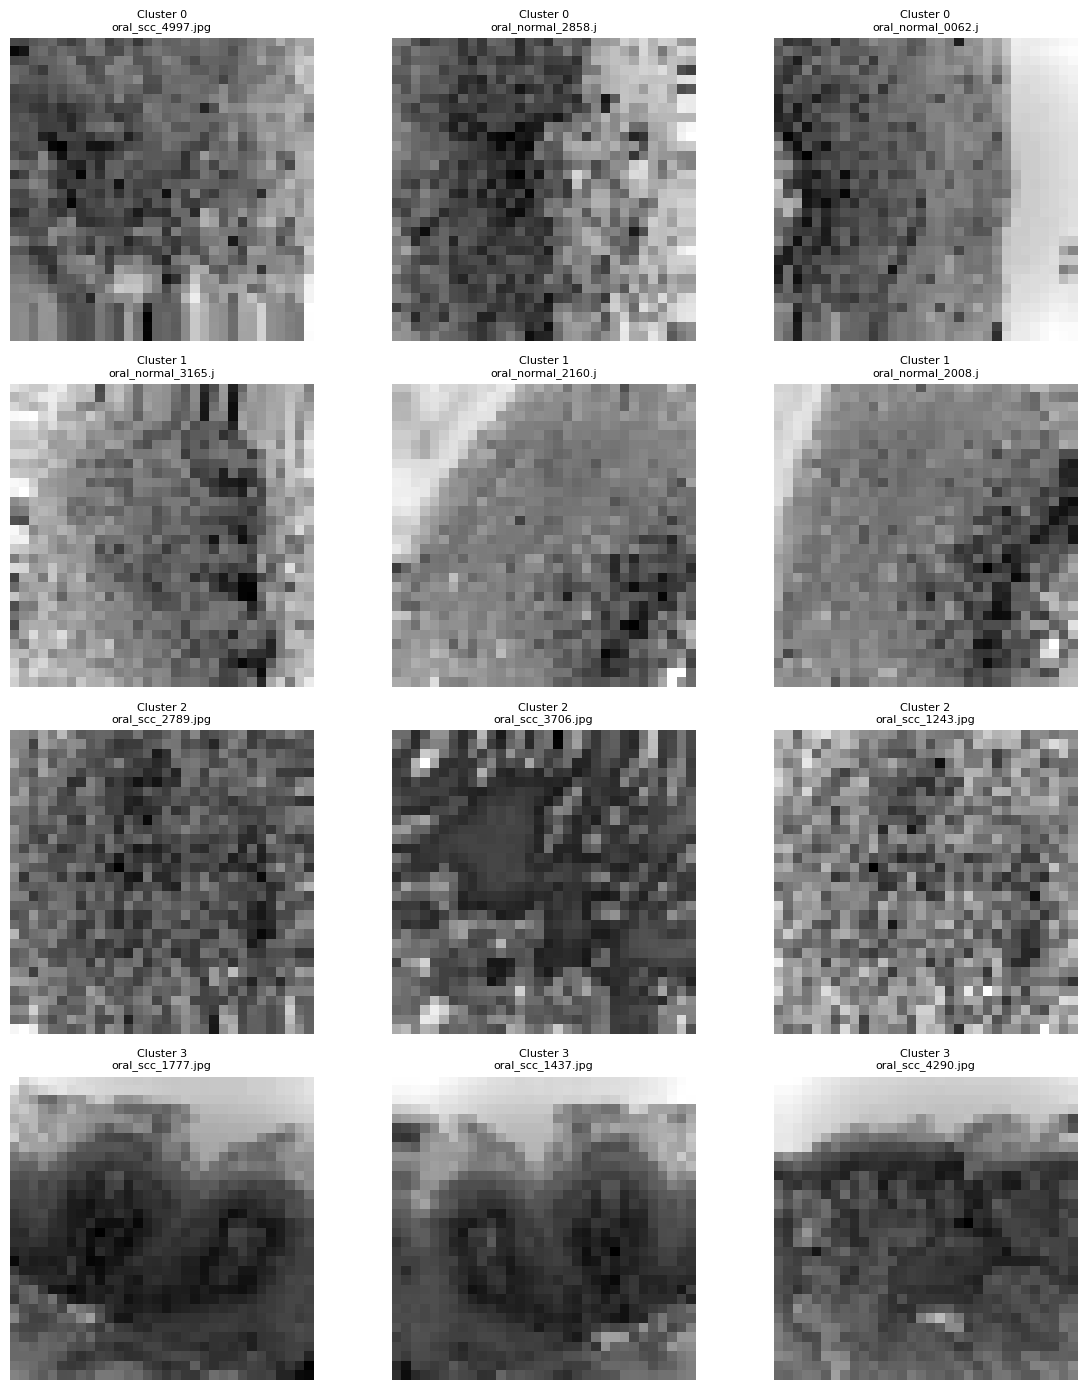

In [8]:
from sklearn.metrics import silhouette_score

sample_size = min(2000, len(X_reduced))
rng = np.random.RandomState(42)
sample_indices = rng.choice(len(X_reduced), size=sample_size, replace=False)
X_sample = X_reduced[sample_indices]
cluster_sample = cluster_ids[sample_indices]

sil_score_real = silhouette_score(X_sample, cluster_sample)
print(f'Silhouette score del clustering real (muestra de {sample_size} imágenes): {sil_score_real:.4f}')

cluster_unique, cluster_counts = np.unique(cluster_ids, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].scatter(X_reduced[:, 0], X_reduced[:, 1], c=cluster_ids, cmap='tab10', s=3, alpha=0.5)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=120, marker='X', label='Centroides')
axes[0].set_title('Clusters de imágenes en el espacio PCA')
axes[0].set_xlabel('Componente PCA 1')
axes[0].set_ylabel('Componente PCA 2')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.2)

axes[1].bar([f'Cluster {cluster_id}' for cluster_id in cluster_unique], cluster_counts, color='steelblue')
axes[1].set_title(f'Distribución de imágenes por cluster\nSilhouette = {sil_score_real:.4f}')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Cantidad de imágenes')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

montage_images = []
montage_titles = []
for cluster_id in cluster_unique:
    cluster_positions = np.where(cluster_ids == cluster_id)[0]
    if len(cluster_positions) == 0:
        continue
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(X_reduced[cluster_positions] - center, axis=1)
    ordered_positions = cluster_positions[np.argsort(distances)]
    for image_index in ordered_positions[:3]:
        montage_images.append(images[image_index])
        montage_titles.append(f'Cluster {cluster_id}\n{used_paths[image_index].name[:18]}')

montage_cols = 3
montage_rows = math.ceil(len(montage_images) / montage_cols)
fig, axes = plt.subplots(montage_rows, montage_cols, figsize=(4 * montage_cols, 3.5 * montage_rows))
axes = np.array(axes).reshape(-1)

for axis in axes:
    axis.axis('off')

for axis, img, title in zip(axes, montage_images, montage_titles):
    axis.imshow(img, cmap='gray')
    axis.set_title(title, fontsize=8)

plt.tight_layout()
plt.show()

### K-Means

El algoritmo de *K-Means* es uno de los métodos más conocidos para hacer *Clustering*, ya que es rápido y sencillo de interpretar. En esta práctica lo usaremos con imágenes locales que primero se reducen a escala de grises y luego se redimensionan a 32x32 antes de aplicar PCA y K-Means. Eso simplifica el análisis y ayuda a entender mejor los grupos visuales.


In [5]:
pca_components = min(50, X.shape[1], X.shape[0] - 1)
pca = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
X_reduced = pca.fit_transform(X)

print('Shape de X reducido:', X_reduced.shape)
print('Varianza explicada acumulada:', round(pca.explained_variance_ratio_.sum(), 4))

Shape de X reducido: (10002, 50)
Varianza explicada acumulada: 0.8501


## 3. Elegir el número de clusters

Como el objetivo aquí es una presentación simple y fácil de interpretar, vamos a fijar `k = 4` para separar las imágenes en cuatro grupos visuales. Esto no significa que el dataset tenga etiquetas reales; los nombres como `normal` o `cancer` solo se usan después de revisar manualmente los clusters representativos.


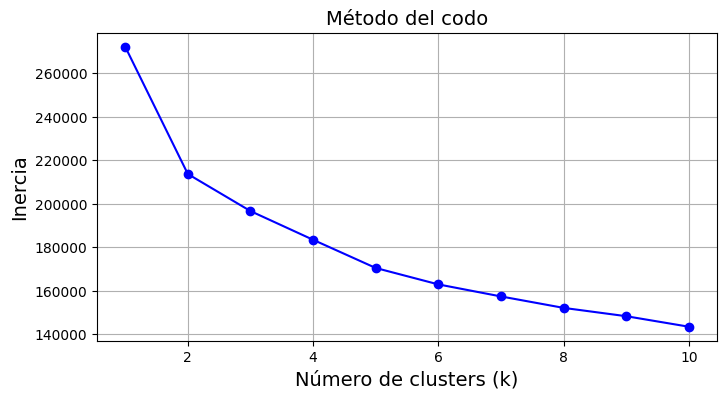

k elegido para la presentación: 4


In [19]:
max_k = 10
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_reduced)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

best_k = 4
print('k elegido para la presentación:', best_k)


### Método del codo

Probamos distintos valores de $k$ y usamos la inercia (*inertia*) para identificar un punto razonable de agrupamiento. El gráfico nos ayuda a ver dónde empieza a disminuir la mejora al aumentar $k$.


In [6]:
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=256, n_init=10)
cluster_ids = kmeans.fit_predict(X_reduced)

unique_clusters, cluster_counts = np.unique(cluster_ids, return_counts=True)
print('Distribución de clusters:')
for cluster_id, count in zip(unique_clusters, cluster_counts):
    print(f' - Cluster {cluster_id}: {count} imágenes')


Distribución de clusters:
 - Cluster 0: 1909 imágenes
 - Cluster 1: 1891 imágenes
 - Cluster 2: 4324 imágenes
 - Cluster 3: 1878 imágenes


### Lectura final con k=4

Después de revisar el método del codo, se fija $k=4$ para mostrar la agrupación final y comparar la distribución de las imágenes.


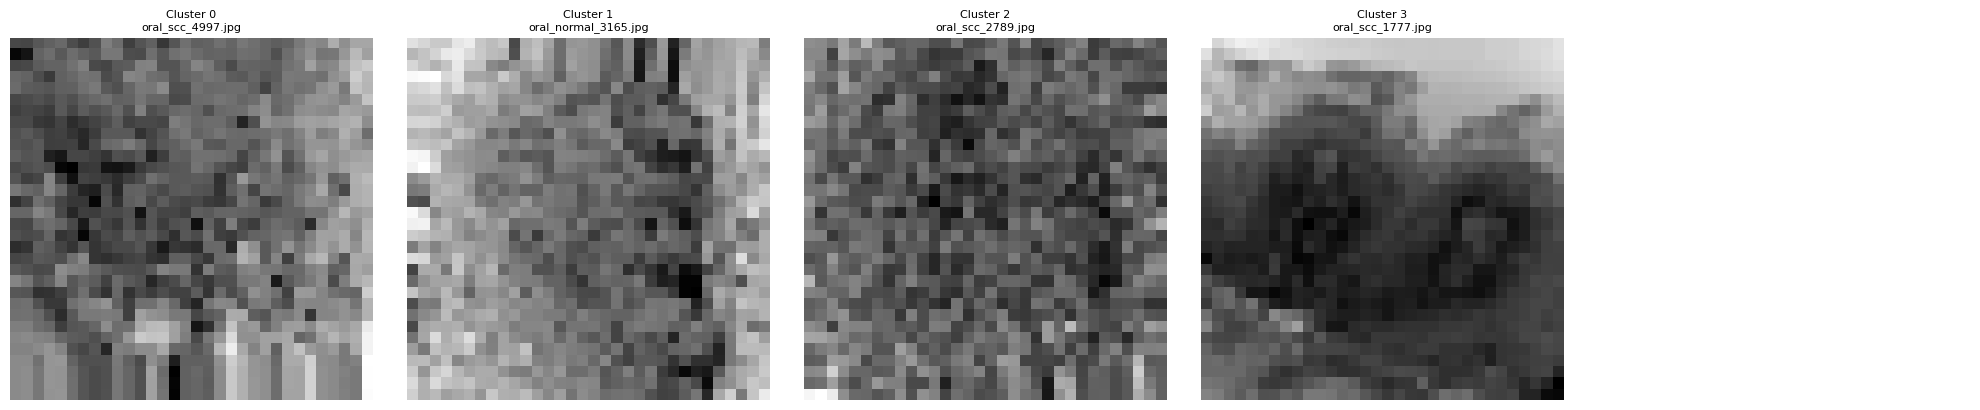

In [21]:
def show_representative_images(images, X_reduced, cluster_ids, centroids, image_paths, n_cols=5):
    representatives = []
    for cluster_id in range(len(centroids)):
        members = np.where(cluster_ids == cluster_id)[0]
        if len(members) == 0:
            continue
        distances = np.linalg.norm(X_reduced[members] - centroids[cluster_id], axis=1)
        representative_index = members[np.argmin(distances)]
        representatives.append(representative_index)

    n_items = len(representatives)
    n_rows = math.ceil(n_items / n_cols)
    _, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx in range(len(axes)):
        axes[idx].axis('off')

    for plot_idx, image_index in enumerate(representatives):
        axes[plot_idx].imshow(images[image_index], cmap='gray')
        axes[plot_idx].set_title(f'Cluster {cluster_ids[image_index]}\n{image_paths[image_index].name}', fontsize=8)

    plt.tight_layout()
    plt.show()

show_representative_images(images, X_reduced, cluster_ids, kmeans.cluster_centers_, used_paths)

### K-Means para aprendizaje semi-supervisado con k=4

El aprendizaje semi-supervisado comprende las técnicas que nos permiten entrenar modelos con datos parcialmente interpretados. En esta práctica, primero agrupamos las imágenes con K-Means y luego asignamos manualmente una interpretación a cada grupo para poder presentar resultados en clase.


In [22]:
# Interpretación manual sugerida de los 4 clusters.
# Ojo: estos nombres no salen automáticamente del algoritmo; se asignan después de revisar las imágenes representativas.
cluster_to_label = {
    0: 'normal',
    1: 'cancer frente',
    2: 'cancer lado izquierdo',
    3: 'cancer lado derecho'
}

if len(cluster_to_label) == 4:
    pseudo_labels = np.array([cluster_to_label[c] for c in cluster_ids])
    print('Interpretación de clusters lista para presentación.')
    for cluster_id, label in cluster_to_label.items():
        print(f'Cluster {cluster_id}: {label}')
else:
    print('Todavia no hay etiquetas suficientes para pasar a la parte semi-supervisada.')


Interpretación de clusters lista para presentación.
Cluster 0: normal
Cluster 1: cancer frente
Cluster 2: cancer lado izquierdo
Cluster 3: cancer lado derecho


## 4. Método del lab7 para KMeans con dataset sintético

Para cubrir el Punto 1 del enunciado, seguimos la misma idea del lab7 auxiliar: primero trabajamos con un conjunto sintético de blobs. El generador permite crear entre 1 y 20 centroides y luego probamos valores de $k$ en ese mismo rango para justificar la elección con inercia y silhouette.


Se generaron 4 centroides sintéticos
Coordenadas de los centroides:
[[-2.50919762  9.01428613]
 [ 4.63987884  1.97316968]
 [-6.87962719 -6.88010959]
 [-8.83832776  7.32352292]]
k sugerido por silhouette: 3


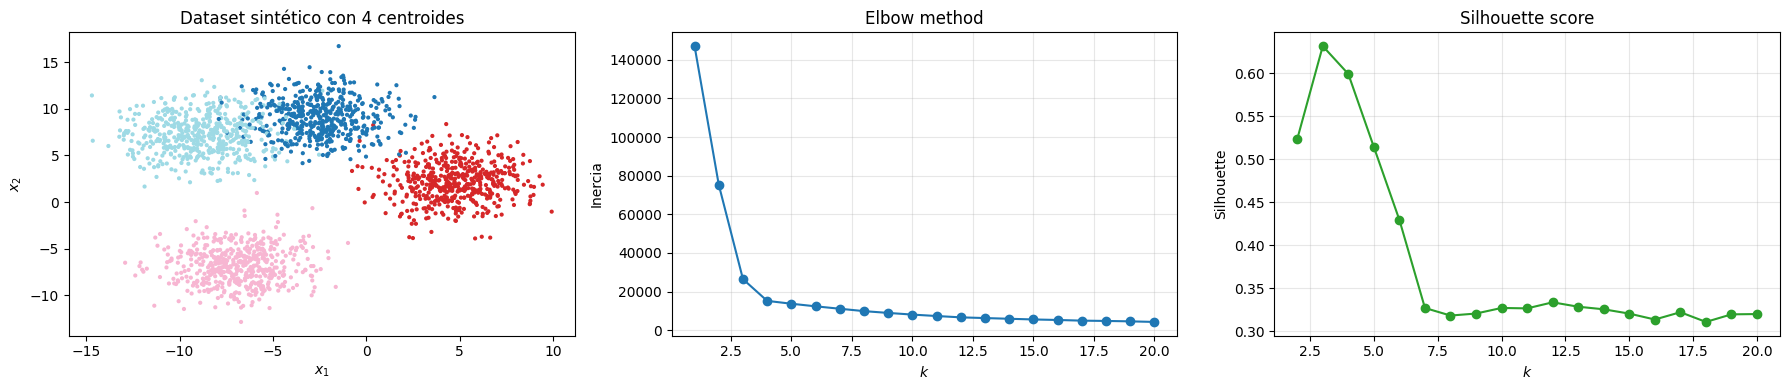

In [2]:
import random
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

random.seed(42)
np.random.seed(42)

n_centers = random.randint(1, 20)
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

X_synth, y_synth = make_blobs(
    n_samples=2000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=42,
)

print(f'Se generaron {n_centers} centroides sintéticos')
print('Coordenadas de los centroides:')
print(blob_centers)

candidate_ks = list(range(1, 21))
inertias = []
silhouette_scores = []

for candidate_k in candidate_ks:
    model = KMeans(n_clusters=candidate_k, random_state=42, n_init=10)
    labels = model.fit_predict(X_synth)
    inertias.append(model.inertia_)
    if candidate_k == 1 or len(np.unique(labels)) < 2:
        silhouette_scores.append(np.nan)
    else:
        silhouette_scores.append(silhouette_score(X_synth, labels))

valid_scores = np.array(silhouette_scores, dtype=float)
best_candidate_k = candidate_ks[int(np.nanargmax(valid_scores))]
print(f'k sugerido por silhouette: {best_candidate_k}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(X_synth[:, 0], X_synth[:, 1], c=y_synth, s=4, cmap='tab20')
axes[0].set_title(f'Dataset sintético con {n_centers} centroides')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')

axes[1].plot(candidate_ks, inertias, 'o-', color='tab:blue')
axes[1].set_title('Elbow method')
axes[1].set_xlabel('$k$')
axes[1].set_ylabel('Inercia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(candidate_ks[1:], valid_scores[1:], 'o-', color='tab:green')
axes[2].set_title('Silhouette score')
axes[2].set_xlabel('$k$')
axes[2].set_ylabel('Silhouette')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Aprendizaje semisupervisado y aprendizaje activo

En esta parte dejamos documentado el flujo completo trabajado en el notebook sobre imágenes reales sin etiquetas. El valor de $k$ usado en K-Means se eligió por interpretación visual y no por la cantidad de muestras, porque el objetivo es formar grupos coherentes de imágenes:

1. Se cargaron 10.002 imágenes locales sin etiquetas desde `C:\Users\elmer\Documents\archive\all unlabeled`.
2. Se redujo la dimensión con PCA para hacer viable el clustering visual.
3. Se aplicó K-Means y se mostró su distribución en el espacio PCA.
4. Se calculó silhouette score sobre una muestra aleatoria del clustering real.
5. Se visualizó un mosaico de imágenes representativas por cluster.
6. Se tomó una pequeña muestra etiquetada de forma manual a partir de los centros más representativos.
7. Se entrenó LabelSpreading como ejemplo de aprendizaje semisupervisado.
8. Se usó LogisticRegression con selección por incertidumbre para el aprendizaje activo.
9. Se visualizaron las muestras más inciertas para priorizar futuras anotaciones.

Esta segunda parte complementa el bloque sintético anterior y muestra cómo pasar de un ejemplo didáctico a un caso real con imágenes médicas locales.

### Lista de verificación para la defensa

- Dataset sintético con centroides entre 1 y 20.
- Separación visual de centroides para verificar el comportamiento de K-Means.
- Método del codo para justificar el número de clusters.
- Silhouette score para evaluar la calidad del agrupamiento.
- Dataset real sin etiquetas con más de 10 atributos o dimensiones y más de 10.000 ejemplos.
- Visualización del clustering real sobre PCA.
- Aplicación de aprendizaje semisupervisado.
- Aplicación de aprendizaje activo.
- Resumen final de todo lo trabajado para presentar en clase.

Resumen del flujo semisupervisado y activo
Imágenes disponibles: 10002
Clusters usados: [0, 1, 2, 3]
Muestras etiquetadas inicialmente por revisión: 20
Distribución de etiquetas propagadas por LabelSpreading:
  Cluster 0 (normal): 1907
  Cluster 1 (cancer frente): 3976
  Cluster 2 (cancer lado izquierdo): 2309
  Cluster 3 (cancer lado derecho): 1810

Muestras sugeridas por aprendizaje activo (mayor incertidumbre):
01. oral_scc_1441.jpg -> pred: cancer lado izquierdo | incertidumbre=1.3830
02. oral_normal_1307.jpg -> pred: normal | incertidumbre=1.3818
03. oral_scc_1320.jpg -> pred: cancer lado derecho | incertidumbre=1.3803
04. oral_normal_2442.jpg -> pred: normal | incertidumbre=1.3793
05. oral_normal_1978.jpg -> pred: cancer lado izquierdo | incertidumbre=1.3773
06. oral_normal_3684.jpg -> pred: cancer lado derecho | incertidumbre=1.3759
07. oral_normal_2151.jpg -> pred: normal | incertidumbre=1.3756
08. oral_normal_2455.jpg -> pred: normal | incertidumbre=1.3737
09. oral_normal_4838

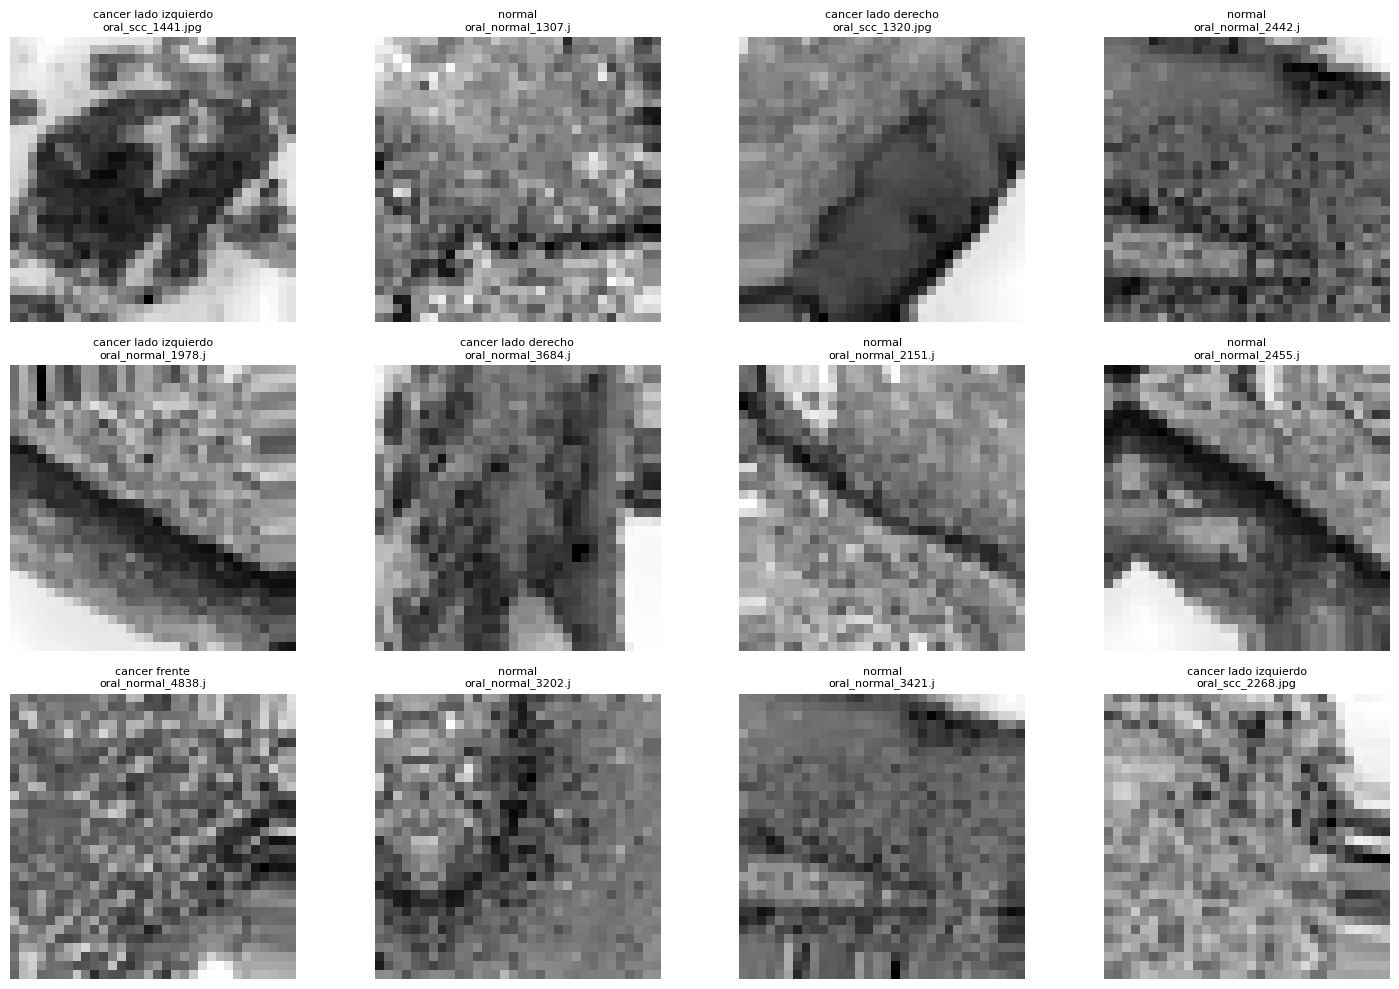

In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.semi_supervised import LabelSpreading
from sklearn.linear_model import LogisticRegression


def load_images(paths, image_size=(32, 32), max_images=None):
    selected_paths = paths if max_images is None else paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert('L').resize(image_size)
            image_arrays.append(np.asarray(img, dtype=np.float32) / 255.0)
    images_local = np.stack(image_arrays)
    flat_local = images_local.reshape(len(images_local), -1)
    return images_local, flat_local, selected_paths


def ensure_base_data():
    global image_paths, images, X, used_paths, X_reduced, cluster_ids, cluster_to_label, kmeans

    if 'image_paths' not in globals():
        data_root = Path(r'C:\Users\elmer\Documents\SIS420\archive')
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        image_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in image_extensions])

    if 'images' not in globals() or 'X' not in globals() or 'used_paths' not in globals():
        images, X, used_paths = load_images(image_paths, image_size=(32, 32), max_images=None)

    if 'X_reduced' not in globals():
        pca_components = min(50, X.shape[1], X.shape[0] - 1)
        pca = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
        X_reduced = pca.fit_transform(X)

    if 'cluster_ids' not in globals():
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        cluster_ids = kmeans.fit_predict(X_reduced)

    if 'cluster_to_label' not in globals():
        cluster_to_label = {
            0: 'normal',
            1: 'cancer frente',
            2: 'cancer lado izquierdo',
            3: 'cancer lado derecho'
        }


ensure_base_data()

n_labeled_per_cluster = 5
labeled_indices = []
for cluster_id in sorted(np.unique(cluster_ids)):
    cluster_positions = np.where(cluster_ids == cluster_id)[0]
    if len(cluster_positions) == 0:
        continue
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(X_reduced[cluster_positions] - center, axis=1)
    ordered_positions = cluster_positions[np.argsort(distances)]
    labeled_indices.extend(ordered_positions[:n_labeled_per_cluster].tolist())

labeled_indices = np.array(sorted(set(labeled_indices)))
semi_supervised_labels = np.full(len(cluster_ids), -1, dtype=int)
semi_supervised_labels[labeled_indices] = cluster_ids[labeled_indices]

label_spread = LabelSpreading(kernel='knn', n_neighbors=15, alpha=0.2, max_iter=30)
label_spread.fit(X_reduced, semi_supervised_labels)
semi_predictions = label_spread.transduction_

active_model = LogisticRegression(max_iter=1000)
active_model.fit(X_reduced[labeled_indices], cluster_ids[labeled_indices])
active_probabilities = active_model.predict_proba(X_reduced)
active_entropy = -np.sum(active_probabilities * np.log(active_probabilities + 1e-12), axis=1)
active_pool = np.setdiff1d(np.arange(len(cluster_ids)), labeled_indices)
query_size = min(12, len(active_pool))
query_candidates = active_pool[np.argsort(active_entropy[active_pool])[-query_size:]][::-1]

print('Resumen del flujo semisupervisado y activo')
print(f'Imágenes disponibles: {len(used_paths)}')
print(f'Clusters usados: {sorted(np.unique(cluster_ids).tolist())}')
print(f'Muestras etiquetadas inicialmente por revisión: {len(labeled_indices)}')
print('Distribución de etiquetas propagadas por LabelSpreading:')
for cluster_id in sorted(cluster_to_label):
    count = int(np.sum(semi_predictions == cluster_id))
    print(f'  Cluster {cluster_id} ({cluster_to_label[cluster_id]}): {count}')

print('\nMuestras sugeridas por aprendizaje activo (mayor incertidumbre):')
for rank, sample_index in enumerate(query_candidates, start=1):
    predicted_cluster = int(np.argmax(active_probabilities[sample_index]))
    print(f'{rank:02d}. {used_paths[sample_index].name} -> pred: {cluster_to_label[predicted_cluster]} | incertidumbre={active_entropy[sample_index]:.4f}')

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.reshape(-1)
for axis in axes:
    axis.axis('off')

for axis, sample_index in zip(axes, query_candidates):
    axis.imshow(images[sample_index], cmap='gray')
    predicted_cluster = int(np.argmax(active_probabilities[sample_index]))
    axis.set_title(f"{cluster_to_label[predicted_cluster]}\n{used_paths[sample_index].name[:18]}", fontsize=8)

plt.tight_layout()
plt.show()


## Conclusiones finales

- El flujo sintético cumple el objetivo de mostrar K-Means con centroides bien separados, junto con el método del codo y silhouette score.
- El caso real de cáncer de boca usa más de 10.000 imágenes sin etiquetas, lo que permite defender el uso de aprendizaje no supervisado.
- La parte semisupervisada y el aprendizaje activo quedan como extensión natural del clustering para mostrar cómo pasar de datos sin etiqueta a un flujo de apoyo a etiquetado humano.
- Para la exposición, lo más importante es mostrar primero el dataset sintético y luego el caso real con el PCA, los clusters, el mosaico de imágenes y las muestras inciertas.
- La coordinación con Helen Janko Sanga es un punto externo al notebook y debe confirmarse fuera del código.